# Happy or Sad Image Classifier


## Step 1: Load dataset

- Import libraries.
- Download the dataset if needed.
- Set the dataset folder path.


In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = Path("./data/data")
if not dataset_path.exists():
    kagglehub.dataset_download(
        "aravindanr22052001/emotiondetection-happy-or-sad",
        output_dir="./data/",
    )

print("Dataset root:", dataset_path.resolve())


/Users/miphu/Projects/DAT301m/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset root: /Users/miphu/Projects/DAT301m/week_2/data/data


## Step 2: Check class folders

- Point to the happy and sad folders.
- Count the images in each class.


In [2]:
happy_path = dataset_path / "happy"
sad_path = dataset_path / "sad"

print("Happy images:", len(list(happy_path.iterdir())))
print("Sad images:", len(list(sad_path.iterdir())))


Happy images: 90
Sad images: 78


## Step 3: Create image generators

- Use `ImageDataGenerator` as required.
- Split data into training and validation sets.
- Keep normalization inside the model.


In [3]:
image_size = (224, 224)
batch_size = 32
seed = 42

tf.keras.utils.set_random_seed(seed)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

image_generator = ImageDataGenerator(
    validation_split=0.2,
)

train_generator = image_generator.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    seed=seed,
    shuffle=True,
)

val_generator = image_generator.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    seed=seed,
    shuffle=False,
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)


Found 134 images belonging to 2 classes.
Found 33 images belonging to 2 classes.
Classes: ['happy', 'sad']


## Step 4: Inspect one batch

- Get one batch from the training generator.
- Check the image and label shapes.


In [4]:
sample_images, sample_labels = next(train_generator)

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


## Step 5: Visualize sample images

- Plot a few images from one batch.
- Show the class label for each image.


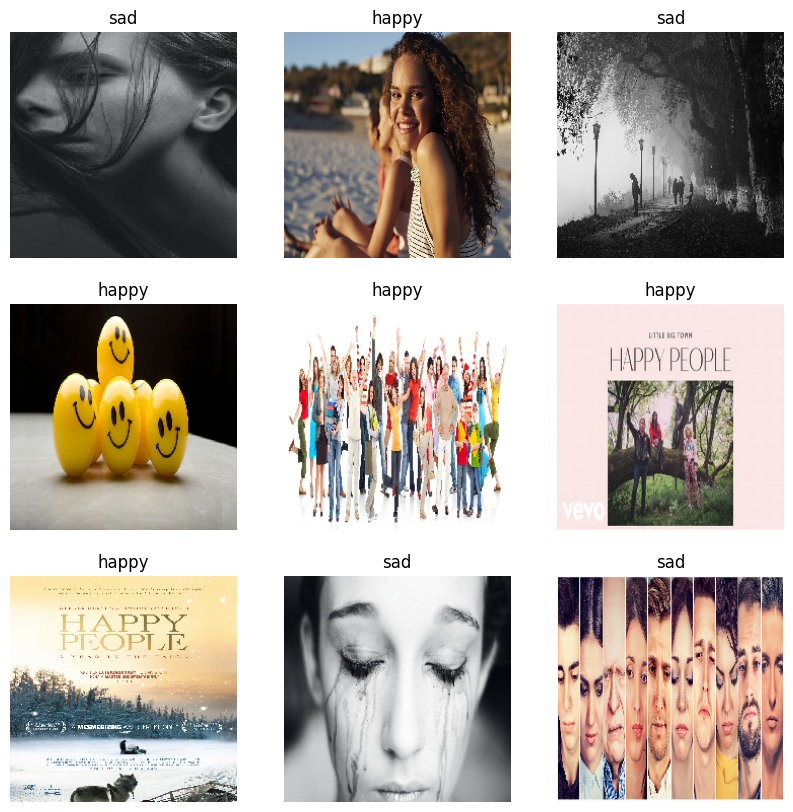

In [5]:
plt.figure(figsize=(10, 10))

for image_index in range(9):
    label_index = int(sample_labels[image_index])
    plt.subplot(3, 3, image_index + 1)
    plt.imshow(sample_images[image_index].astype("uint8"))
    plt.title(class_names[label_index])
    plt.axis("off")

plt.show()


## Step 6: Build a CNN model

- Use the baseline CNN.
- Add rescaling inside the model.
- Keep the architecture simple.


In [6]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=image_size + (3,)),
    tf.keras.layers.Rescaling(1.0 / 255),
    tf.keras.layers.Conv2D(8, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4, seed=seed),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.summary()


2026-05-23 20:33:11.148897: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-23 20:33:11.148941: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-23 20:33:11.148962: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-23 20:33:11.148997: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-23 20:33:11.149027: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 614,481 (2.34 MB)

 Trainable params: 614,481 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train with callbacks

- Compile the model.
- Report `80%`, `85%`, and `90%` accuracy milestones.
- Reset generators before training for more stable runs.


Epoch 1/30


2026-05-23 20:33:12.043882: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - accuracy: 0.4925 - loss: 0.8097 - val_accuracy: 0.5455 - val_loss: 0.6982
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - accuracy: 0.5149 - loss: 0.7161 - val_accuracy: 0.4545 - val_loss: 0.7303
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.4627 - loss: 0.7934 - val_accuracy: 0.4545 - val_loss: 0.7092
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.5149 - loss: 0.7132 - val_accuracy: 0.5152 - val_loss: 0.6883
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.5448 - loss: 0.6897 - val_accuracy: 0.5455 - val_loss: 0.6863
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.5970 - loss: 0.6793 - val_accuracy: 0.4848 - val_loss: 0.6826
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.5970 - loss: 0.6682 - val_accuracy: 0.4848 - val_loss: 0.6737
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.5672 - loss: 0.6599 - val_accuracy: 0.4848 - val_loss: 0.6521
Epo

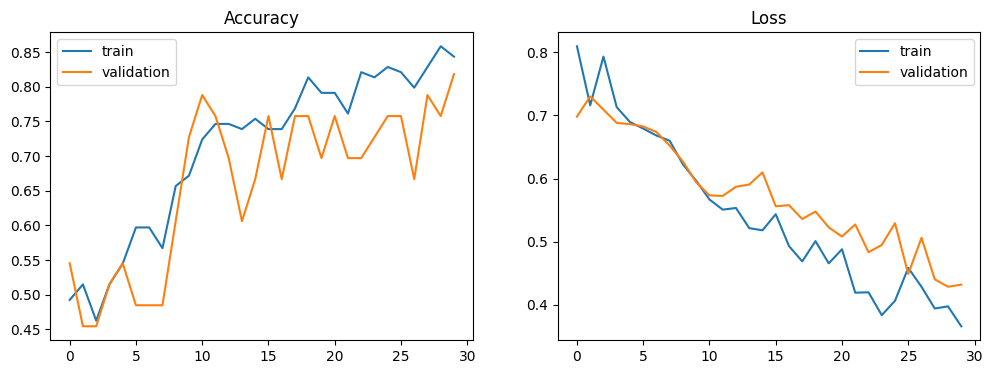

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

def milestone(epoch, logs):
    accuracy = logs.get("accuracy", 0)

    if accuracy >= 0.90 and not hasattr(milestone, "_reached_90"):
        print(f"Epoch {epoch + 1}: reached 90% accuracy.")
        milestone._reached_90 = True
    elif accuracy >= 0.85 and not hasattr(milestone, "_reached_85"):
        print(f"Epoch {epoch + 1}: reached 85% accuracy.")
        milestone._reached_85 = True
    elif accuracy >= 0.80 and not hasattr(milestone, "_reached_80"):
        print(f"Epoch {epoch + 1}: reached 80% accuracy.")
        milestone._reached_80 = True

train_generator.reset()
val_generator.reset()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[tf.keras.callbacks.LambdaCallback(on_epoch_end=milestone)],
)

loss, accuracy = model.evaluate(val_generator)
print(f"Validation accuracy: {accuracy:.2%}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()

plt.show()


## Step 8: Test one image

- Pick a random image.
- Predict the label.
- Show the result.


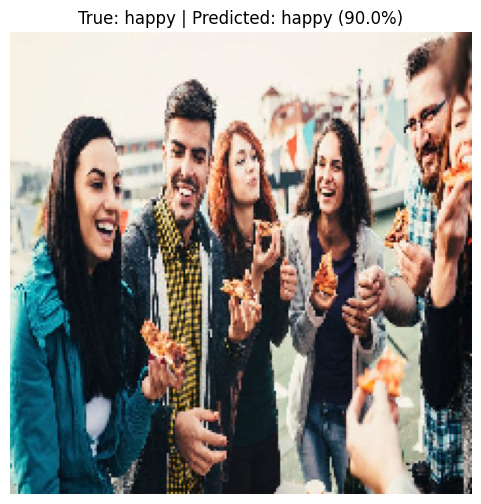

In [12]:
import random

label = random.choice(class_names)
image_path = random.choice(list((dataset_path / label).iterdir()))

image = tf.keras.utils.load_img(image_path, target_size=image_size)
input_array = tf.keras.utils.img_to_array(image)
input_array = tf.expand_dims(input_array, 0)

prediction = model.predict(input_array, verbose=0)[0][0]
predicted_label = class_names[int(prediction > 0.5)]
confidence = prediction if prediction > 0.5 else 1 - prediction

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"True: {label} | Predicted: {predicted_label} ({confidence:.1%})")
plt.axis("off")
plt.show()
